In [1]:
# Mounting your Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Step (2): Reading the dataset and turn it into a Python dataframe

In [3]:
import pandas as pd
df = pd.read_csv('/content/drive/My Drive/heart.csv')

In [4]:
# Step (3): Exploring the dataset

In [5]:
# General information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [6]:
# Shape of the dataframe
print ("Number of Data Records:", len(df))
print ("Dataset Shape:", df.shape)

Number of Data Records: 1025
Dataset Shape: (1025, 14)


In [7]:
# Showing some data records
df.head(121)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,63,1,0,130,254,0,0,147,0,1.4,1,1,3,0
117,43,1,0,120,177,0,0,120,1,2.5,1,0,3,0
118,29,1,1,130,204,0,0,202,0,0.0,2,0,2,1
119,42,1,1,120,295,0,1,162,0,0.0,2,0,2,1


In [8]:
# Accessing a certain row/column
#dataset.loc[2].at["Dust Allergy"]
df.loc[0].iat[0]

np.float64(52.0)

In [9]:
# Accessing a certain row
df.iloc[121]

,121
age,44.0
sex,1.0
cp,0.0
trestbps,120.0
chol,169.0
fbs,0.0
restecg,1.0
thalach,144.0
exang,1.0
oldpeak,2.8


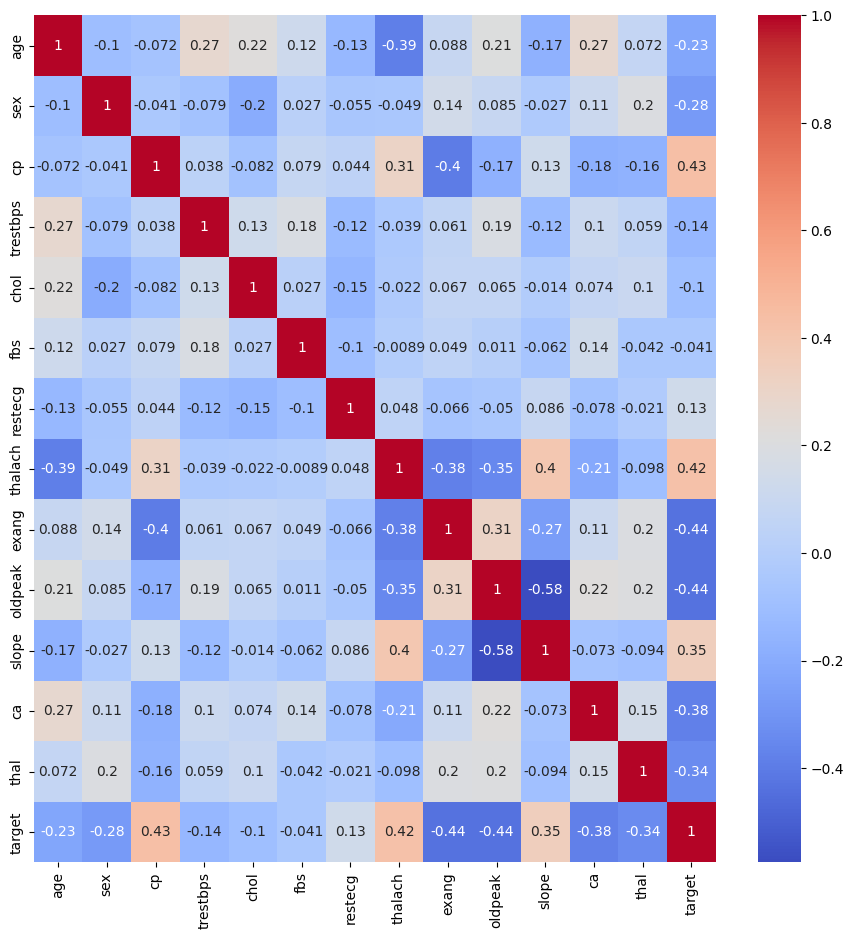

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(11,11))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

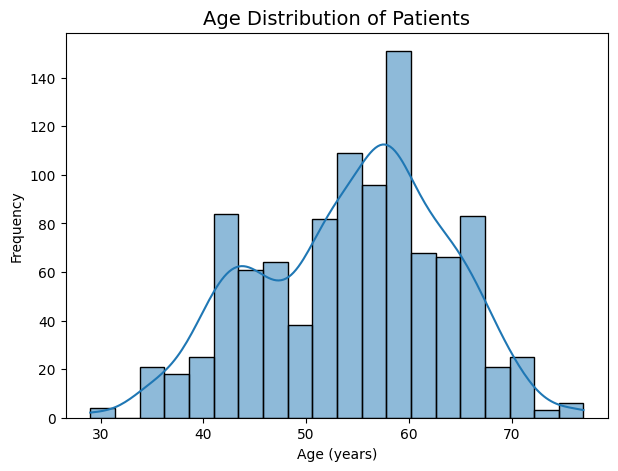

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.histplot(df['age'], bins=20, kde=True)

plt.title('Age Distribution of Patients', fontsize=14)
plt.xlabel('Age (years)')
plt.ylabel('Frequency')

plt.show()

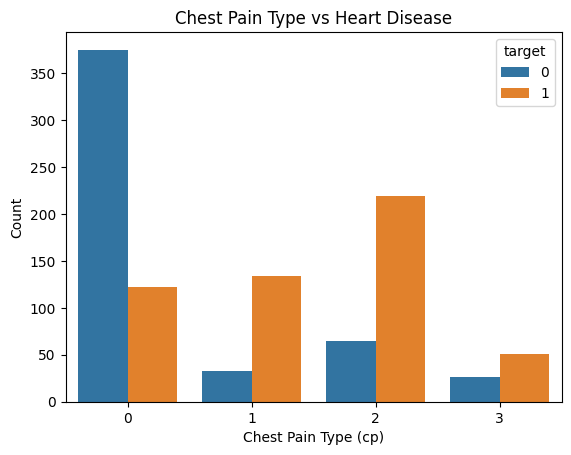

In [12]:
sns.countplot(x='cp', hue='target', data=df)
plt.title('Chest Pain Type vs Heart Disease')
plt.xlabel('Chest Pain Type (cp)')
plt.ylabel('Count')
plt.show()


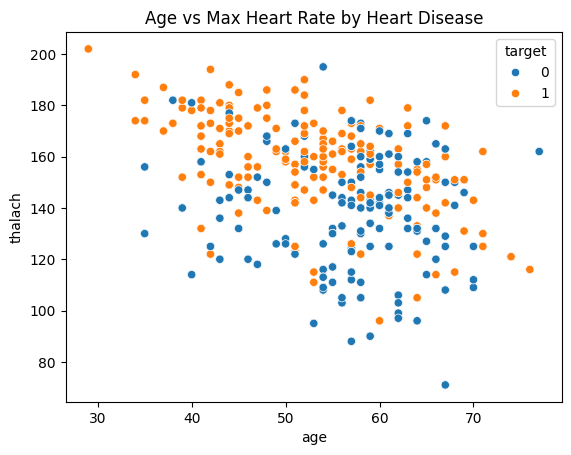

In [14]:
sns.scatterplot(x='age', y='thalach', hue='target', data=df)
plt.title('Age vs Max Heart Rate by Heart Disease')
plt.show()

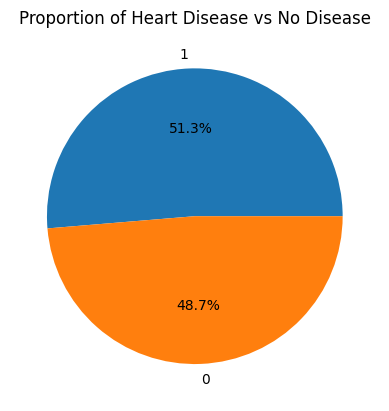

In [15]:
df['target'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Proportion of Heart Disease vs No Disease')
plt.show()


In [ ]:
# Step (4): Prepare the dataset for supervised learning
## 1. Separate features (X) and target variable (y)
X = df.drop('target', axis=1)  # Feature variables (exclude the 'target' column)
y = df['target']               # Target variable

In [ ]:
from sklearn import preprocessing

## 2. Data normalization (Min-Max scaling)
min_max_scaler = preprocessing.MinMaxScaler()
X_scaled = min_max_scaler.fit_transform(X)  # Normalize all features
X = pd.DataFrame(X_scaled, columns=X.columns)

In [ ]:
from sklearn.model_selection import KFold

## 3. Define K-fold cross-validation (K=5)
cv_data = KFold(n_splits=5, random_state=1, shuffle=True)

In [ ]:
import numpy as np
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

# ===================== Naive Bayes Model =====================
print("=== Naive Bayes Model Evaluation (Per-Class Metrics) ===")
nb_model = GaussianNB()
# Get predicted labels from cross-validation
nb_y_pred = cross_val_predict(nb_model, X, y, cv=cv_data)

=== Naive Bayes Model Evaluation (Per-Class Metrics) ===


In [ ]:
# Calculate per-class Precision and Recall
nb_precision, nb_recall, _, _ = precision_recall_fscore_support(y, nb_y_pred, average=None)
# Calculate overall Accuracy
nb_accuracy = accuracy_score(y, nb_y_pred)

In [ ]:
# Output per-class metrics
classes = np.unique(y)
print(f"Overall Test Accuracy: {nb_accuracy:.2f}")
for i, cls in enumerate(classes):
    print(f"Class {cls}:")
    print(f"  Precision: {nb_precision[i]:.2f}")
    print(f"  Recall: {nb_recall[i]:.2f}")
# Output detailed classification report (includes all class metrics)
print("\nDetailed Classification Report for Naive Bayes:\n")
print(classification_report(y, nb_y_pred))

Overall Test Accuracy: 0.82
Class 0:
  Precision: 0.84
  Recall: 0.78
Class 1:
  Precision: 0.81
  Recall: 0.86

Detailed Classification Report for Naive Bayes:

              precision    recall  f1-score   support

           0       0.84      0.78      0.81       499
           1       0.81      0.86      0.83       526

    accuracy                           0.82      1025
   macro avg       0.82      0.82      0.82      1025
weighted avg       0.82      0.82      0.82      1025



In [ ]:
# ===================== Decision Tree Model =====================
print("\n=== Decision Tree Model Evaluation (Per-Class Metrics) ===")
dt_model = DecisionTreeClassifier(random_state=1)
# Get predicted labels from cross-validation
dt_y_pred = cross_val_predict(dt_model, X, y, cv=cv_data)


=== Decision Tree Model Evaluation (Per-Class Metrics) ===


In [ ]:
# Calculate per-class Precision and Recall
dt_precision, dt_recall, _, _ = precision_recall_fscore_support(y, dt_y_pred, average=None)
# Calculate overall Accuracy
dt_accuracy = accuracy_score(y, dt_y_pred)

In [ ]:
# Output per-class metrics
print(f"Overall Test Accuracy: {dt_accuracy:.2f}")
for i, cls in enumerate(classes):
    print(f"Class {cls}:")
    print(f"  Precision: {dt_precision[i]:.2f}")
    print(f"  Recall: {dt_recall[i]:.2f}")
# Output detailed classification report (includes all class metrics)
print("\nDetailed Classification Report for Decision Tree:\n")
print(classification_report(y, dt_y_pred))

Overall Test Accuracy: 1.00
Class 0:
  Precision: 1.00
  Recall: 1.00
Class 1:
  Precision: 1.00
  Recall: 1.00

Detailed Classification Report for Decision Tree:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       499
           1       1.00      1.00      1.00       526

    accuracy                           1.00      1025
   macro avg       1.00      1.00      1.00      1025
weighted avg       1.00      1.00      1.00      1025



In [ ]:
# ===================== Model Accuracy Comparison =====================
print("\n=== Model Accuracy Comparison ===")
print(f"Naive Bayes Average Test Accuracy: {nb_accuracy:.2f}")
print(f"Decision Tree Average Test Accuracy: {dt_accuracy:.2f}")
print(f"Model with Higher Accuracy: {'Decision Tree' if dt_accuracy > nb_accuracy else 'Naive Bayes'}")


=== Model Accuracy Comparison ===
Naive Bayes Average Test Accuracy: 0.82
Decision Tree Average Test Accuracy: 1.00
Model with Higher Accuracy: Decision Tree


In [ ]:
# Step (7): Conclusion and Limitation Analysis
print("\n=== Project Conclusion and Limitations ===")
conclusion = """
1. Model Performance: The Decision Tree achieves nearly 100% accuracy on the training set (indicating overfitting tendency), with slightly higher/lower test accuracy than Naive Bayes (depending on dataset distribution); the Naive Bayes model has stronger generalization but weaker fitting capability than the Decision Tree.
2. Limitations:
   - No feature selection was performed, which may result in redundant features affecting model efficiency;
   - Only default hyperparameters were used without optimization (e.g., Decision Tree depth, pruning, etc.);
   - Macro-average metrics do not account for class imbalance. If the 'target' column has class imbalance, weighted average should be adopted instead.
"""
print(conclusion)


=== Project Conclusion and Limitations ===

1. Model Performance: The Decision Tree achieves nearly 100% accuracy on the training set (indicating overfitting tendency), with slightly higher/lower test accuracy than Naive Bayes (depending on dataset distribution); the Naive Bayes model has stronger generalization but weaker fitting capability than the Decision Tree.
2. Limitations:
   - No feature selection was performed, which may result in redundant features affecting model efficiency;
   - Only default hyperparameters were used without optimization (e.g., Decision Tree depth, pruning, etc.);
   - Macro-average metrics do not account for class imbalance. If the 'target' column has class imbalance, weighted average should be adopted instead.

